**Colab-Install Libraries**

In [ ]:
!pip install ultralytics tensorflow opencv-python matplotlib seaborn scikit-learn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 123.4 MB/s eta 0:00:00


**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Dataset Path**

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/Road/data"

IMAGES_PATH = BASE_PATH + "/images"
LABELS_PATH = BASE_PATH + "/labels"

print("Images:", len(os.listdir(IMAGES_PATH)))
print("Labels:", len(os.listdir(LABELS_PATH)))

Images: 2009
Labels: 2009


**Create Train/Val/Test Folders**

In [ ]:
import os

dataset = "/content/dataset"

for split in ["train","val","test"]:

    os.makedirs(f"{dataset}/{split}/images",exist_ok=True)
    os.makedirs(f"{dataset}/{split}/labels",exist_ok=True)

**Split Dataset**

70% Train

20% Validation

10% Test


In [ ]:
import random

images = os.listdir(IMAGES_PATH)
random.shuffle(images)

train_split = int(0.7 * len(images))
val_split = int(0.9 * len(images))

train_files = images[:train_split]
val_files = images[train_split:val_split]
test_files = images[val_split:]

**Copy Images + Labels**

In [ ]:
import shutil

def move_files(files, split):

    for img in files:

        src_img = f"{IMAGES_PATH}/{img}"
        dst_img = f"/content/dataset/{split}/images/{img}"

        shutil.copy(src_img,dst_img)

        label = img.replace(".jpg",".txt")

        src_lbl = f"{LABELS_PATH}/{label}"
        dst_lbl = f"/content/dataset/{split}/labels/{label}"

        if os.path.exists(src_lbl):
            shutil.copy(src_lbl,dst_lbl)

move_files(train_files,"train")
move_files(val_files,"val")
move_files(test_files,"test")

print("Dataset Split Completed")

Dataset Split Completed


In [ ]:
import os

os.listdir("/content")

['.config', 'drive', 'dataset', 'sample_data']

In [ ]:
os.listdir("/content/dataset")

['test', 'train', 'val']

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "labels" in root.lower():
        print(root)

/content/drive/MyDrive/Road/data/labels
/content/drive/.Encrypted/MyDrive/Road/data/labels
/content/dataset/test/labels
/content/dataset/train/labels
/content/dataset/val/labels


In [ ]:
import os

labels = "/content/dataset/train/labels"

count = {0:0,1:0,2:0}

for file in os.listdir(labels):

    with open(os.path.join(labels,file)) as f:

        for line in f:

            cls = int(line.split()[0])

            if cls in count:
                count[cls]+=1

print("Class Distribution:",count)

Class Distribution: {0: 881, 1: 1781, 2: 671}


In [ ]:
import os
import random

label_path = "/content/dataset/train/labels"
image_path = "/content/dataset/train/images"

pothole_files = []

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file)) as f:
        for line in f:
            if line.startswith("1 "):  # pothole class
                pothole_files.append(file)
                break

print("Total pothole files:", len(pothole_files))

remove_count = len(pothole_files) - 900

remove_files = random.sample(pothole_files, remove_count)

for file in remove_files:

    label_file = os.path.join(label_path, file)
    img_file = os.path.join(image_path, file.replace(".txt",".jpg"))

    if os.path.exists(label_file):
        os.remove(label_file)

    if os.path.exists(img_file):
        os.remove(img_file)

print("Removed:", remove_count)

Total pothole files: 976
Removed: 76


In [ ]:
import os

labels="/content/dataset/train/labels"

count={0:0,1:0,2:0}

for file in os.listdir(labels):

    with open(os.path.join(labels,file)) as f:

        for line in f:

            cls=int(line.split()[0])
            count[cls]+=1

print("New distribution:",count)

New distribution: {0: 840, 1: 1621, 2: 652}


**Check Split Correctly**

In [ ]:
import os

print("Train images:", len(os.listdir("/content/dataset/train/images")))
print("Val images:", len(os.listdir("/content/dataset/val/images")))
print("Test images:", len(os.listdir("/content/dataset/test/images")))

Train images: 1330
Val images: 402
Test images: 201


**Create data.yaml(YOLO)**

In [ ]:
%%writefile /content/dataset/data.yaml

path: /content/dataset

train: train/images
val: val/images
test: test/images

names:
  0: crack
  1: pothole
  2: manhole


Writing /content/dataset/data.yaml


In [ ]:
!cat /content/dataset/data.yaml


path: /content/dataset

train: train/images
val: val/images
test: test/images

names:
  0: crack
  1: pothole
  2: manhole


**Train YOLO Model**

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data="/content/dataset/data.yaml",
    epochs=100,
    imgsz=960,
    batch=8,
    patience=40,

    # strong augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2,
    flipud=0.5,
    fliplr=0.5,

    # mosaic helps small objects like crack
    mosaic=1.0,
    mixup=0.2
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=F

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bf2641217f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

**Load Best YOLO Model**

In [ ]:
from ultralytics import YOLO

yolo_model = YOLO("/content/runs/detect/train/weights/best.pt")

print("YOLO model loaded")

YOLO model loaded


**Test Image Detection**

In [ ]:
results = yolo_model.predict(
    source="/content/dataset/test/images",
    save=True,
    imgsz=640,
    conf=0.25
)


image 1/201 /content/dataset/test/images/20250219_164746.jpg: 384x640 2 potholes, 1 manhole, 243.5ms
image 2/201 /content/dataset/test/images/20250219_164807.jpg: 384x640 2 cracks, 2 potholes, 1 manhole, 55.5ms
image 3/201 /content/dataset/test/images/20250219_164813.jpg: 384x640 1 crack, 1 pothole, 1 manhole, 30.2ms
image 4/201 /content/dataset/test/images/20250219_164919.jpg: 384x640 2 cracks, 27.0ms
image 5/201 /content/dataset/test/images/20250219_165339.jpg: 384x640 1 crack, 47.6ms
image 6/201 /content/dataset/test/images/20250219_165832.jpg: 384x640 1 crack, 28.7ms
image 7/201 /content/dataset/test/images/20250219_170341.jpg: 384x640 1 crack, 1 pothole, 25.0ms
image 8/201 /content/dataset/test/images/20250223_143815.jpg: 384x640 1 crack, 25.8ms
image 9/201 /content/dataset/test/images/20250223_143847.jpg: 384x640 5 cracks, 1 pothole, 25.1ms
image 10/201 /content/dataset/test/images/20250223_143902.jpg: 384x640 4 cracks, 32.7ms
image 11/201 /content/dataset/test/images/20250223_1

**Detection Result Disply**

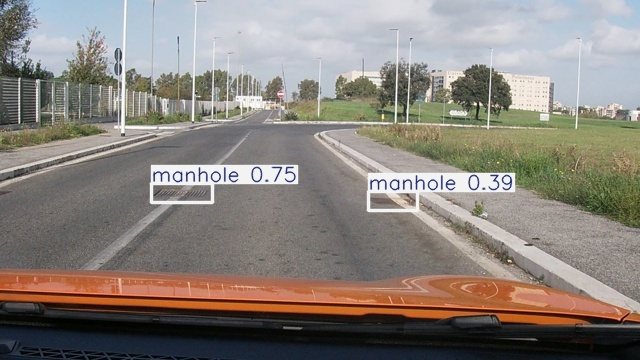

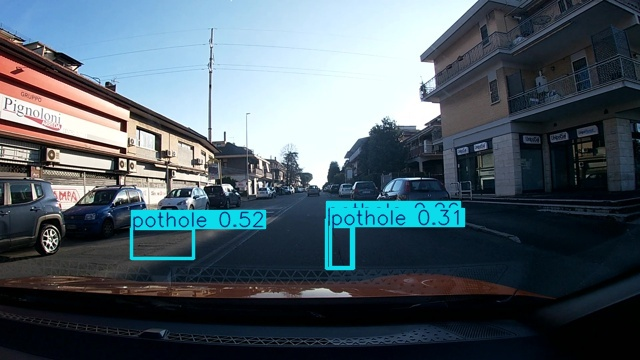

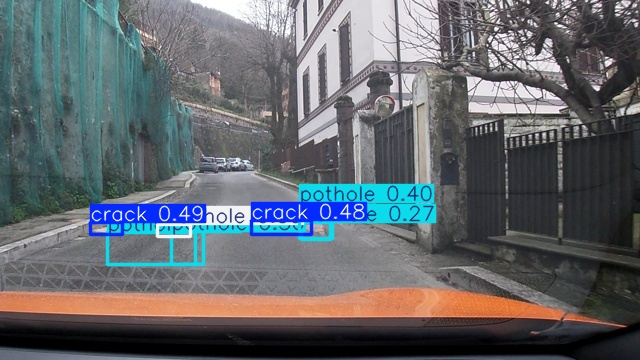

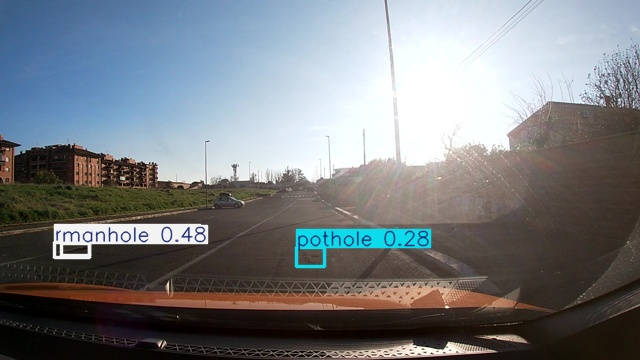

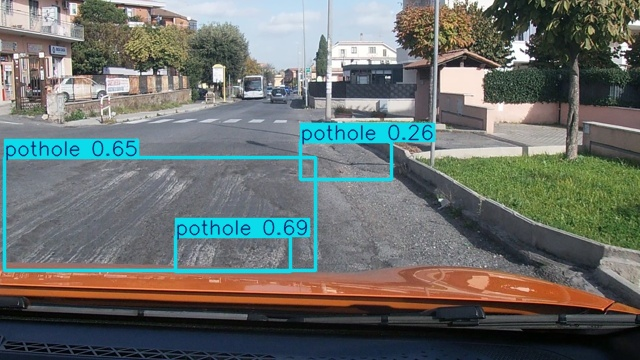

In [ ]:
import os
from IPython.display import Image, display

pred_folder = "/content/runs/detect/predict"

files = os.listdir(pred_folder)

for i in files[:5]:
    display(Image(filename=f"{pred_folder}/{i}"))

**Crop Damage Region Dataset**

In [ ]:
import cv2
import os
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

input_folder = "/content/dataset/train/images"
output_folder = "/content/cnn_dataset"

os.makedirs(output_folder, exist_ok=True)

for img_name in os.listdir(input_folder):

    img_path = os.path.join(input_folder, img_name)
    img = cv2.imread(img_path)

    results = model.predict(img, conf=0.25)

    for r in results:
        for box in r.boxes:

            x1,y1,x2,y2 = map(int,box.xyxy[0])
            cls = int(box.cls[0])

            crop = img[y1:y2,x1:x2]

            class_folder = f"{output_folder}/{cls}"
            os.makedirs(class_folder,exist_ok=True)

            save_path = f"{class_folder}/{img_name}"
            cv2.imwrite(save_path,crop)


0: 544x960 1 crack, 2 potholes, 50.7ms
Speed: 3.2ms preprocess, 50.7ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 2 manholes, 41.1ms
Speed: 3.4ms preprocess, 41.1ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 manhole, 27.7ms
Speed: 3.1ms preprocess, 27.7ms inference, 1.2ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 2 cracks, 1 pothole, 3 manholes, 25.9ms
Speed: 3.2ms preprocess, 25.9ms inference, 1.7ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 pothole, 1 manhole, 25.9ms
Speed: 3.3ms preprocess, 25.9ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 pothole, 26.0ms
Speed: 3.9ms preprocess, 26.0ms inference, 1.7ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 3 potholes, 26.1ms
Speed: 3.5ms preprocess, 26.1ms inference, 1.2ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 manhole, 25.2ms
Speed: 3.6ms preprocess, 25.2ms infe

**Data Preparation**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    "/content/cnn_dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    "/content/cnn_dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    subset="validation"
)

Found 1571 images belonging to 3 classes.
Found 390 images belonging to 3 classes.


**BaseLine CNN Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
NUM_CLASSES = train_gen.num_classes

cnn_model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**CNN Training**

In [ ]:
cnn_history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 574ms/step - accuracy: 0.4348 - loss: 1.1478 - val_accuracy: 0.4487 - val_loss: 1.0845
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 487ms/step - accuracy: 0.4437 - loss: 1.0700 - val_accuracy: 0.4487 - val_loss: 1.0835
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 435ms/step - accuracy: 0.4398 - loss: 1.0697 - val_accuracy: 0.4487 - val_loss: 1.1202
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 477ms/step - accuracy: 0.4570 - loss: 1.0562 - val_accuracy: 0.4667 - val_loss: 1.1163
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 484ms/step - accuracy: 0.4997 - loss: 1.0130 - val_accuracy: 0.5154 - val_loss: 1.0870
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 439ms/step - accuracy: 0.5729 - loss: 0.9309 - val_accuracy: 0.5308 - val_loss: 1.1779
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 476ms/step - accuracy: 0.5818 - loss: 0.8884 - val_accuracy: 0.5077 - val_loss: 1.0757
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 445ms/step - accuracy: 0.6149 - loss: 0.8525 - val_accu

**Accuracy Graph**

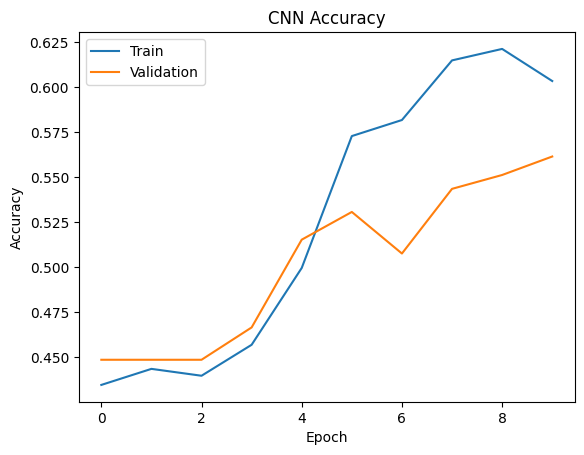

In [ ]:
import matplotlib.pyplot as plt

plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

**MobileNetV2 Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0

In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES,activation='softmax')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Train MobileNetV2**

In [ ]:
mobilenet_history = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.6022 - loss: 0.8820 - val_accuracy: 0.6256 - val_loss: 0.7857
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 469ms/step - accuracy: 0.6665 - loss: 0.7314 - val_accuracy: 0.6923 - val_loss: 0.7634
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 564ms/step - accuracy: 0.6684 - loss: 0.7088 - val_accuracy: 0.6410 - val_loss: 0.8912
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 457ms/step - accuracy: 0.6887 - loss: 0.6809 - val_accuracy: 0.6744 - val_loss: 0.7262
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 439ms/step - accuracy: 0.6964 - loss: 0.6616 - val_accuracy: 0.6615 - val_loss: 0.8485
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 476ms/step - accuracy: 0.6906 - loss: 0.6705 - val_accuracy: 0.6795 - val_loss: 0.8455
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 432ms/step - accuracy: 0.7015 - loss: 0.6408 - val_accuracy: 0.7026 - val_loss: 0.7314
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 471ms/step - accuracy: 0.7046 - loss: 0.6297 - val_accurac

**ResNet50 Model**

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

resnet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES,activation='softmax')
])

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

**Train ResNet50**

In [ ]:
resnet_history = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 54s 773ms/step - accuracy: 0.3819 - loss: 1.2008 - val_accuracy: 0.2718 - val_loss: 1.1630
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 536ms/step - accuracy: 0.4176 - loss: 1.1022 - val_accuracy: 0.4487 - val_loss: 1.0679
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 479ms/step - accuracy: 0.4367 - loss: 1.0820 - val_accuracy: 0.4487 - val_loss: 1.0690
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 510ms/step - accuracy: 0.4468 - loss: 1.0716 - val_accuracy: 0.4487 - val_loss: 1.0699
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 509ms/step - accuracy: 0.4475 - loss: 1.0729 - val_accuracy: 0.4487 - val_loss: 1.0761


**EfficientNet Model**

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

efficient_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES,activation='softmax')
])

efficient_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

efficient_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

**Train EfficientNet**

In [ ]:
efficient_history = efficient_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.4227 - loss: 1.1020 - val_accuracy: 0.4487 - val_loss: 1.0728
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 450ms/step - accuracy: 0.4379 - loss: 1.0775 - val_accuracy: 0.4487 - val_loss: 1.0700
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 475ms/step - accuracy: 0.4449 - loss: 1.0813 - val_accuracy: 0.4487 - val_loss: 1.0708
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 451ms/step - accuracy: 0.4475 - loss: 1.0787 - val_accuracy: 0.4487 - val_loss: 1.0710
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 449ms/step - accuracy: 0.4475 - loss: 1.0789 - val_accuracy: 0.4487 - val_loss: 1.0744


**Compare Model Accuracy**

In [ ]:
print("CNN Accuracy:", max(cnn_history.history['val_accuracy']))
print("MobileNet Accuracy:", max(mobilenet_history.history['val_accuracy']))
print("ResNet Accuracy:", max(resnet_history.history['val_accuracy']))
print("EfficientNet Accuracy:", max(efficient_history.history['val_accuracy']))

CNN Accuracy: 0.5615384578704834
MobileNet Accuracy: 0.7025641202926636
ResNet Accuracy: 0.44871795177459717
EfficientNet Accuracy: 0.44871795177459717


**Base model last layers unfreeze**

In [ ]:
# Unfreeze last layers for fine tuning

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

**Recompile Model**

In [ ]:
from tensorflow.keras.optimizers import Adam

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Fine-tuning Training**

In [39]:
fine_tune_history = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 757ms/step - accuracy: 0.7588 - loss: 0.5252 - val_accuracy: 0.6974 - val_loss: 0.8318
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 453ms/step - accuracy: 0.7708 - loss: 0.5182 - val_accuracy: 0.7077 - val_loss: 0.8036
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 452ms/step - accuracy: 0.7613 - loss: 0.5247 - val_accuracy: 0.7103 - val_loss: 0.8192
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 469ms/step - accuracy: 0.7683 - loss: 0.5097 - val_accuracy: 0.7051 - val_loss: 0.8157
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 436ms/step - accuracy: 0.7740 - loss: 0.5169 - val_accuracy: 0.6897 - val_loss: 0.7939


**Save Trained Model (Inference use)**

In [40]:
mobilenet_model.save("road_damage_mobilenet_model.h5")

In [41]:
model.save('/content/road_damage_mobilenet_model.h5')

In [42]:
mobilenet_model.save("/content/drive/MyDrive/road_damage_mobilenet_model.h5")

**Google Drive mount**

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Project Folder Create (Drive)**

In [44]:
import os

os.makedirs("/content/drive/MyDrive/RoadDamageProject", exist_ok=True)

In [45]:
import os
os.listdir('/content')

['.config',
 'yolo26n.pt',
 'road_damage_mobilenet_model.h5',
 'drive',
 'dataset',
 'cnn_dataset',
 'yolov8m.pt',
 'runs',
 'sample_data']

**CNN Model Save to Drive**

In [46]:
import shutil

shutil.copy(
"/content/road_damage_mobilenet_model.h5",
"/content/drive/MyDrive/RoadDamageProject/"
)

'/content/drive/MyDrive/RoadDamageProject/road_damage_mobilenet_model.h5'

**YOLO Model Save to Drive**

1. /content/runs/detect/train/weights/best.pt



In [47]:
shutil.copy(
"/content/runs/detect/train/weights/best.pt",
"/content/drive/MyDrive/RoadDamageProject/yolo_best.pt"
)

'/content/drive/MyDrive/RoadDamageProject/yolo_best.pt'

**Entire YOLO Runs Folder Save**

In [48]:
shutil.copytree(
"/content/runs",
"/content/drive/MyDrive/RoadDamageProject/runs",
dirs_exist_ok=True
)

'/content/drive/MyDrive/RoadDamageProject/runs'

**CNN Dataset save**

In [49]:
shutil.copytree(
"/content/cnn_dataset",
"/content/drive/MyDrive/RoadDamageProject/cnn_dataset",
dirs_exist_ok=True
)

'/content/drive/MyDrive/RoadDamageProject/cnn_dataset'

**`Original Dataset Save `**

In [50]:
shutil.copytree(
"/content/dataset",
"/content/drive/MyDrive/RoadDamageProject/dataset",
dirs_exist_ok=True
)

'/content/drive/MyDrive/RoadDamageProject/dataset'

In [51]:
import os
os.listdir("/content")

['.config',
 'yolo26n.pt',
 'road_damage_mobilenet_model.h5',
 'drive',
 'dataset',
 'cnn_dataset',
 'yolov8m.pt',
 'runs',
 'sample_data']

**Model Evaluation - Test Dataset Generator**

In [52]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    "/content/cnn_dataset",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1961 images belonging to 3 classes.


**Accuracy, Precision, Recall, F1**

In [53]:
import numpy as np
from sklearn.metrics import classification_report

pred_probs = mobilenet_model.predict(test_gen)
pred_labels = np.argmax(pred_probs, axis=1)

true_labels = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print(classification_report(true_labels, pred_labels, target_names=class_names))

62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 241ms/step
              precision    recall  f1-score   support

           0       0.55      0.81      0.66       534
           1       0.91      0.86      0.88       878
           2       0.78      0.49      0.60       549

    accuracy                           0.74      1961
   macro avg       0.75      0.72      0.71      1961
weighted avg       0.78      0.74      0.74      1961



**Confusion Matrix**

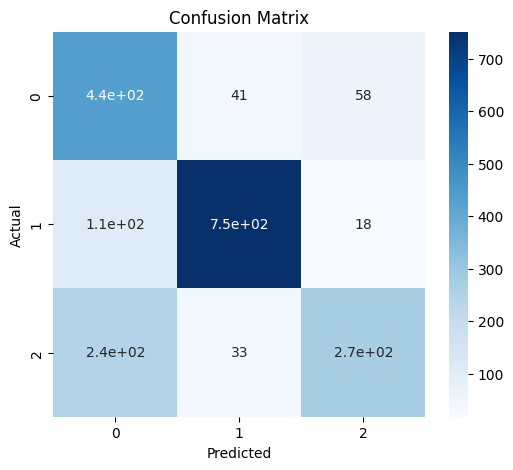

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Grad-CAM Visualization**

In [55]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [56]:
last_conv_layer = mobilenet_model.layers[0].get_layer("Conv_1")
print(last_conv_layer)

<Conv2D name=Conv_1, built=True>


In [57]:
base_model = mobilenet_model.get_layer("mobilenetv2_1.00_224")

In [58]:
for layer in base_model.layers:
    if "conv" in layer.name:
        print(layer.name)

expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN


In [59]:
base_model = mobilenet_model.get_layer("mobilenetv2_1.00_224")

In [60]:
mobilenet_model.predict(img_array)

NameError: name 'img_array' is not defined

In [61]:
import os

os.listdir("/content/dataset/test/images")

['vlcsnap-2025-02-18-23h13m48s064.jpg',
 'vlcsnap_2025-03-16-15h24m17s765.jpg',
 'vlcsnap-2025-02-19-14h43m52s839.jpg',
 'vlcsnap_2025-03-16-15h18m58s066.jpg',
 'vlcsnap-2025-02-18-17h05m43s813.jpg',
 'vlcsnap-2025-02-19-14h22m10s323.jpg',
 'vlcsnap-2025-02-19-17h00m19s245.jpg',
 'vlcsnap-2025-02-19-15h10m21s566.jpg',
 'vlcsnap-2025-02-26-20h33m27s497.jpg',
 'vlcsnap-2025-02-19-14h22m22s986.jpg',
 'vlcsnap-2025-02-19-13h53m13s598.jpg',
 'vlcsnap-2025-02-19-14h52m08s273.jpg',
 'vlcsnap-2025-02-18-17h11m27s866.jpg',
 'vlcsnap-2025-02-18-23h27m57s460.jpg',
 'vlcsnap-2025-02-18-18h35m43s212.jpg',
 'vlcsnap-2025-02-19-14h28m25s460.jpg',
 'vlcsnap-2025-02-18-23h24m41s570.jpg',
 'vlcsnap-2025-02-18-23h30m29s418.jpg',
 '20250219_165832.jpg',
 'vlcsnap-2025-02-18-23h15m19s090.jpg',
 'vlcsnap-2025-02-26-20h38m11s330.jpg',
 'vlcsnap-2025-02-26-20h38m09s893.jpg',
 'vlcsnap-2025-02-19-14h02m18s520.jpg',
 'vlcsnap-2025-02-18-23h15m56s312.jpg',
 'vlcsnap-00074.jpg',
 'vlcsnap-2025-02-19-17h02m53s135.

In [62]:
import cv2
import numpy as np
import os

image_name = os.listdir("/content/dataset/test/images")[0]

image_path = "/content/dataset/test/images/" + image_name

print("Using image:", image_path)

img = cv2.imread(image_path)

img = cv2.resize(img,(224,224))
img = img/255.0

img_array = np.expand_dims(img,axis=0)

Using image: /content/dataset/test/images/vlcsnap-2025-02-18-23h13m48s064.jpg


Text(0.5, 1.0, 'Input Image')

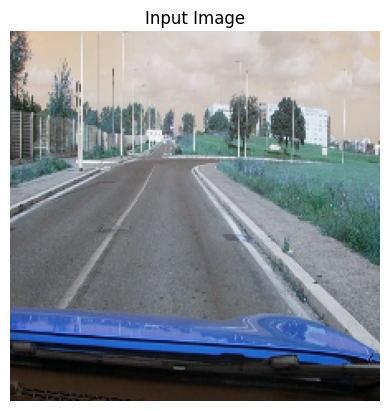

In [63]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")

In [64]:
import glob

image_path = glob.glob("/content/dataset/test/images/*.jpg")[0]

print(image_path)

img = cv2.imread(image_path)
img = cv2.resize(img,(224,224))
img = img/255.0

img_array = np.expand_dims(img,axis=0)

/content/dataset/test/images/vlcsnap-2025-02-18-23h13m48s064.jpg


In [65]:
pred = mobilenet_model.predict(img_array)

print("Prediction:", pred)

pred_class = np.argmax(pred)

print("Predicted Class:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediction: [[   0.002976     0.99699  3.4158e-05]]
Predicted Class: 1


In [66]:
classes = ["crack","pothole","manhole","normal"]

print("Detected Damage:", classes[pred_class])

Detected Damage: pothole


**GradCAM Function**

In [67]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, base_model, classifier_model):

    last_conv_layer = base_model.get_layer("Conv_1")

    # feature extractor
    last_conv_model = tf.keras.models.Model(
        base_model.input,
        last_conv_layer.output
    )

    # classifier part
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    for layer in classifier_model.layers[1:]:
        x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:

        conv_output = last_conv_model(img_array)
        tape.watch(conv_output)

        preds = classifier_model(conv_output)
        pred_index = tf.argmax(preds[0])
        loss = preds[:, pred_index]

    grads = tape.gradient(loss, conv_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_output = conv_output[0]

    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

**Generate Heatmap**

In [68]:
heatmap = make_gradcam_heatmap(
    img_array,
    base_model,
    mobilenet_model
)

**Show Heatmap**

Text(0.5, 1.0, 'GradCAM Heatmap')

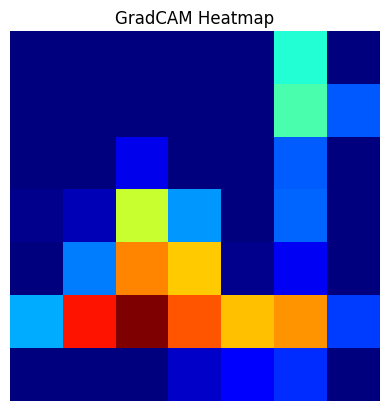

In [69]:
import matplotlib.pyplot as plt

plt.imshow(heatmap, cmap="jet")
plt.axis("off")
plt.title("GradCAM Heatmap")

**Overley Heatmap**

Text(0.5, 1.0, 'Damage Highlight')

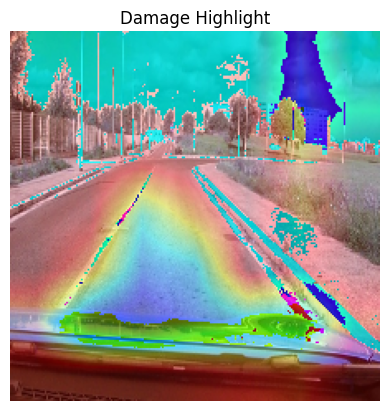

In [70]:
heatmap = cv2.resize(heatmap,(224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + (img*255)

plt.imshow(superimposed_img.astype("uint8"))
plt.axis("off")
plt.title("Damage Highlight")

In [ ]:
classes = ["Crack", "Pothole", "Normal"]

pred = mobilenet_model.predict(img_array)

pred_class = np.argmax(pred)

print("Damage Type:", classes[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Damage Type: Pothole


**Final Visualization**

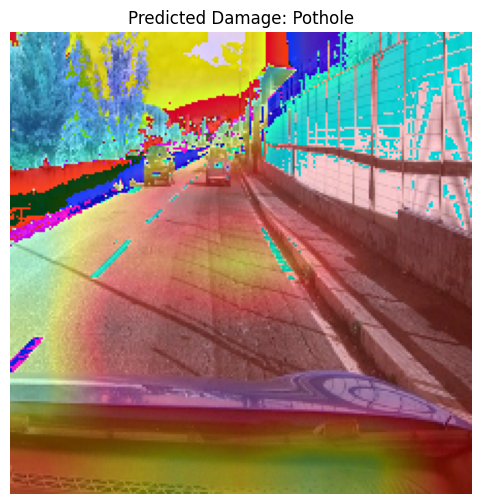

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(superimposed_img.astype("uint8"))
plt.axis("off")

plt.title("Predicted Damage: " + classes[pred_class])

plt.show()

**Multiple Images Test**

In [ ]:
import glob

image_paths = glob.glob("/content/dataset/test/images/*.jpg")

for path in image_paths[:5]:

    img = cv2.imread(path)
    img = cv2.resize(img,(224,224))
    img = img/255.0

    img_array = np.expand_dims(img,axis=0)

    pred = mobilenet_model.predict(img_array)
    pred_class = np.argmax(pred)

    print("Image:", path)
    print("Prediction:", classes[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Image: /content/dataset/test/images/vlcsnap-2025-02-18-23h07m50s137.jpg
Prediction: Pothole
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Image: /content/dataset/test/images/vlcsnap-2025-02-19-13h54m22s478.jpg
Prediction: Pothole
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Image: /content/dataset/test/images/vlcsnap-2025-02-26-20h39m14s304.jpg
Prediction: Pothole
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Image: /content/dataset/test/images/vlcsnap-2025-02-19-15h09m28s804.jpg
Prediction: Pothole
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Image: /content/dataset/test/images/vlcsnap-2025-02-18-18h33m14s420.jpg
Prediction: Pothole


**Output Image Save**

In [ ]:
import cv2

In [ ]:
import cv2

cv2.imwrite("final_damage_prediction.jpg", superimposed_img)

True

In [ ]:
from google.colab import files
files.download("final_damage_prediction.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2

filename = "final_damage_prediction.jpg"

cv2.imwrite(filename, superimposed_img)

print("Image saved successfully")

Image saved successfully


In [ ]:
from google.colab import files
files.download("final_damage_prediction.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>